# Gradient Boosting Analysis for CS2 Match Prediction

In this notebook, we will conduct a Gradient Boosting analysis on the engineered dataset to predict the outcome of CS2 matches (`team1_win`). We will use a time-based 80/20 split to account for the temporal nature of the data.

In [1]:
# AI Used to format markdown and used to conform that the steps done make sense given context.

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv("../../data/rolling_feature_engineered_tier_1_games.csv")
print(f"Initial shape: {df.shape}")

Initial shape: (5539, 84)


In [3]:
# Preprocessing
# Convert datetime to datetime objects and sort
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Define columns to drop (non-features)
cols_to_drop = [
    'team1', 'team2', 'team1_id', 'team2_id', 
    'game_id', 'match_id', 'tournament', 
    'map_id', 'map_name', 'datetime',
    'team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id',
    'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id'
]

# Target variable
y = df['team1_win']

# Features
X = df.drop(columns=['team1_win'] + cols_to_drop)

print(f"Features shape: {X.shape}")

Features shape: (5539, 63)


In [4]:
# Time-based 80/20 split
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 4431, Test size: 1108


In [5]:
# Train Gradient Boosting Classifier
gbm = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
gbm.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [6]:
# Predictions
y_pred = gbm.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.5578

Confusion Matrix:
[[144 345]
 [145 474]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.29      0.37       489
           1       0.58      0.77      0.66       619

    accuracy                           0.56      1108
   macro avg       0.54      0.53      0.51      1108
weighted avg       0.54      0.56      0.53      1108



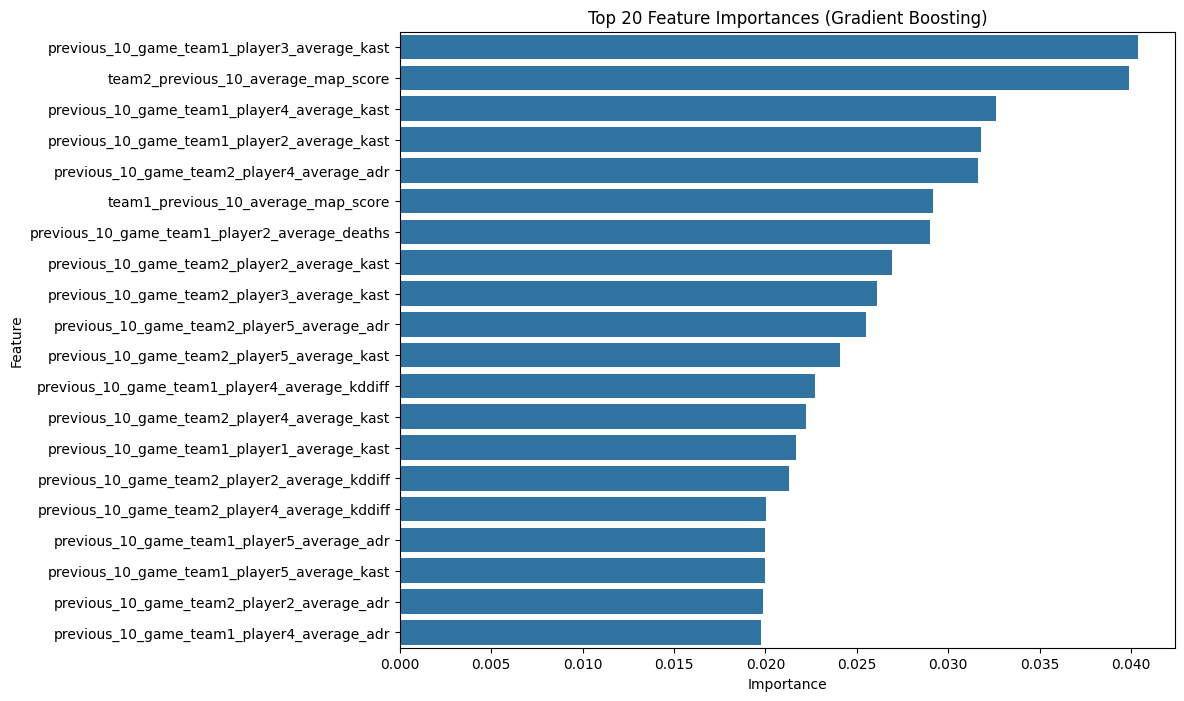

In [7]:
# Feature Importance
importances = gbm.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Gradient Boosting)')
plt.show()